In [1]:
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
import torch
print(f"Torch version: {torch.__version__}")
import cv2
import numpy as np
from ultralytics import YOLO    
import os
from PIL import Image
from torchvision import transforms
from IPython.display import display, clear_output 
from collections import defaultdict



Ultralytics version: 8.4.23
Torch version: 2.10.0+cu128


In [2]:

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.rand(10000,10000).to(device)
print(x.device)

2.10.0+cu128
12.8
True
NVIDIA GeForce RTX 5060 Laptop GPU
cuda:0


In [3]:
!nvidia-smi

Tue Mar 17 21:38:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P2             15W /   60W |     507MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
model = YOLO('yolo26n.pt')
video_path = r"data/traffic.mp4"
cap = cv2.VideoCapture(video_path)

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

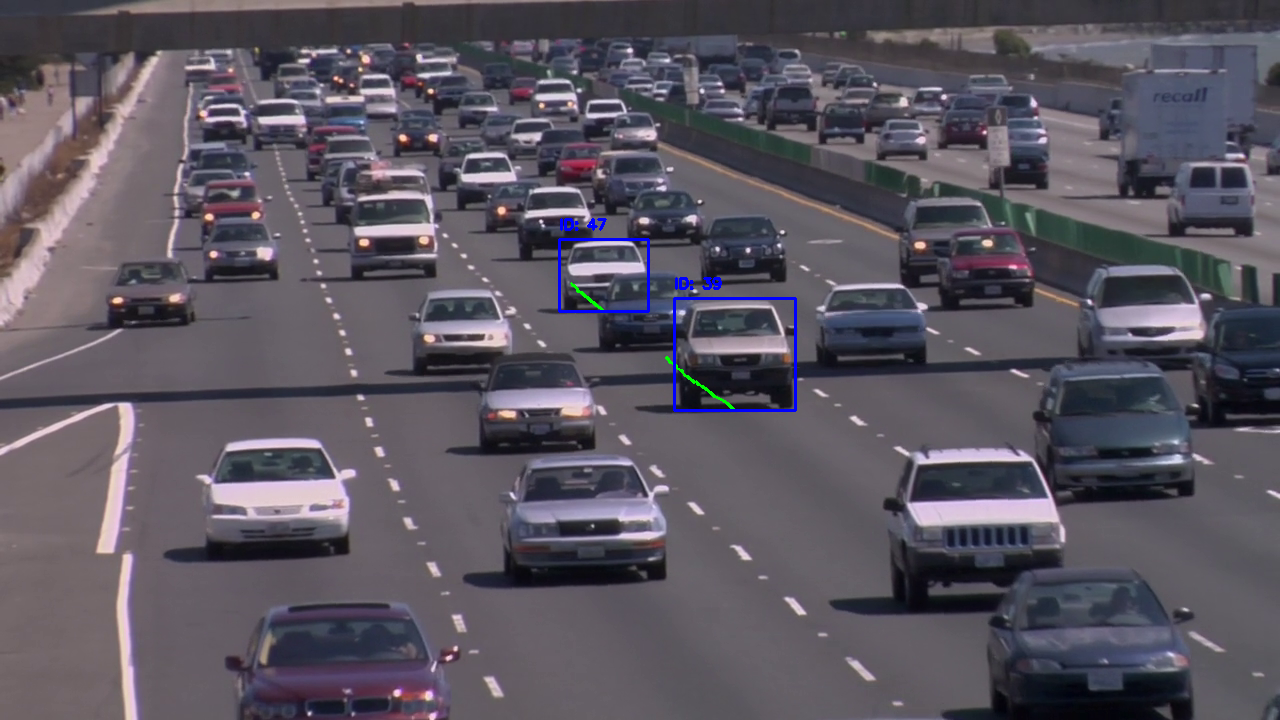

Performing prediction on 6 slices.
Stopped
Save Video


In [17]:
import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output
import supervision as sv
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path='yolo26n.pt',
    confidence_threshold=0.1,
    image_size = 1568,
    device=device
)

tracker = sv.ByteTrack(track_activation_threshold=0.1, lost_track_buffer=120)
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('traffic_slicing.mp4', fourcc, fps, (frame_width, frame_height))

track_history = defaultdict(lambda: [])

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = get_sliced_prediction(
            frame,
            detection_model,
            slice_height=640,
            slice_width=640,
        )

        xyxy = []
        confidences = []
        class_ids = []
        
        for pred in results.object_prediction_list:
            xyxy.append([pred.bbox.minx, pred.bbox.miny, pred.bbox.maxx, pred.bbox.maxy])
            confidences.append(pred.score.value)
            class_ids.append(pred.category.id)
            
        if len(xyxy) > 0:
            detections = sv.Detections(
                xyxy=np.array(xyxy),
                confidence=np.array(confidences),
                class_id=np.array(class_ids)
            )
        else:
            detections = sv.Detections.empty() 

        detections = tracker.update_with_detections(detections)
        annotated_frame = frame.copy()

        detections = tracker.update_with_detections(detections)
        annotated_frame = frame.copy()

        if len(detections) > 0 and detections.tracker_id is not None:
            for bbox, track_id in zip(detections.xyxy, detections.tracker_id):
                x1, y1, x2, y2 = bbox
                
                x_center = (x1 + x2) / 2
                y_bottom = y2 
                
                track = track_history[track_id]
                track.append((float(x_center), float(y_bottom)))  
                
                if len(track) > 30: 
                    track.pop(0)
                
                points = np.array(track).astype(np.int32).reshape((-1, 1, 2))
                cv2.polylines(annotated_frame, [points], isClosed=False, color=(0, 255, 0), thickness=2)
                
                cv2.rectangle(annotated_frame, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
                
                cv2.putText(annotated_frame, f"ID: {track_id}", (int(x1), int(y1) - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        out.write(annotated_frame)
        annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(annotated_frame_rgb)

        clear_output(wait=True)
        display(img)

except KeyboardInterrupt:
    print("Stopped")

finally:
    if 'cap' in locals():
        cap.release()
    if 'out' in locals():
        out.release()
    cv2.destroyAllWindows()
    print("Save Video")